# CLIP ViT-L/14 Spatial Stream for Deepfake Detection

This notebook trains the CLIP spatial stream using:
- **Model**: `CLIPClassifier` (ViT-L/14 with LN-Tuning + gradient checkpointing)
- **Dataset**: `InMemoryImageDataset` (all tensors pre-loaded into RAM with shard caching)
- **Loss**: CrossEntropyLoss
- **Optimizer**: Adam (β₁=0.9, β₂=0.999, no weight decay)
- **AMP**: bfloat16
- **Augmentation**: Asymmetric — ColorJitter + JPEG applied only to fake images (p=0.2)
- **Label Mapping**: Fake = 0, Real = 1

**Note:** The results shown in this notebook may differ from those reported in the final report, as no fixed random seed was set during training. Variations in initialization, data shuffling, and GPU non-determinism can lead to slightly different outcomes across runs.

In [26]:
import sys, os, warnings
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

warnings.filterwarnings('ignore')
sys.path.insert(0, os.path.abspath('..'))

from configs import CLIPStreamConfig
from models.image_detector import CLIPClassifier
from data_loaders.image_dataset import InMemoryImageDataset
from engine.trainer import train_one_epoch, EarlyStopping, unpack_single
from engine.evaluator import evaluate, compute_metrics
from common.augmentation import create_clip_transforms
from common.checkpoint import save_best_model, save_checkpoint
from common.visualization import (
    plot_training_history, plot_roc_curve, plot_confusion_matrix
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

torch.backends.cudnn.benchmark = True

Using device: cuda


## 1. Configuration

In [21]:
cfg = CLIPStreamConfig()
print(cfg)

CLIPStreamConfig(clip_model_name='openai/clip-vit-large-patch14', num_classes=2, epochs=50, batch_size=128, learning_rate=8e-05, weight_decay=0.0, scheduler='cosine', scheduler_t_max=50, scheduler_eta_min=5e-05, early_stopping_patience=10, early_stopping_mode='max', num_workers=16, crop_size=224, perf=PerformanceConfig(num_workers=16, pin_memory=True, persistent_workers=True, prefetch_factor=3, cudnn_benchmark=True, use_amp=True, compile_model=False, compile_backend='inductor'))


## 2. Datasets & DataLoaders

In [3]:
DATA_ROOT = '../data/image'
perf = cfg.perf

train_dataset = InMemoryImageDataset(os.path.join(DATA_ROOT, 'train'))
val_dataset   = InMemoryImageDataset(os.path.join(DATA_ROOT, 'val'))
test_dataset  = InMemoryImageDataset(os.path.join(DATA_ROOT, 'test'))

# With in-memory data, workers just index into a tensor — fewer needed.
loader_kwargs = dict(
    num_workers=0,
    pin_memory=perf.pin_memory,
)

train_loader = DataLoader(train_dataset, batch_size=cfg.batch_size, shuffle=True,  drop_last=True, **loader_kwargs)
val_loader   = DataLoader(val_dataset,   batch_size=cfg.batch_size, shuffle=False, **loader_kwargs)
test_loader  = DataLoader(test_dataset,  batch_size=cfg.batch_size, shuffle=False, **loader_kwargs)

print(f'Train batches: {len(train_loader)}, Val: {len(val_loader)}, Test: {len(test_loader)}')

Loading shard ../data/image\train\_shard.pt …
  27960 samples | Fake: 13990, Real: 13970
  shape=(27960, 3, 224, 224), dtype=torch.float32, RAM=16.8 GB
Loading shard ../data/image\val\_shard.pt …
  5991 samples | Fake: 2996, Real: 2995
  shape=(5991, 3, 224, 224), dtype=torch.float32, RAM=3.6 GB
Loading shard ../data/image\test\_shard.pt …
  5981 samples | Fake: 2992, Real: 2989
  shape=(5981, 3, 224, 224), dtype=torch.float32, RAM=3.6 GB
Train batches: 218, Val: 47, Test: 47


## 3. Model, Optimizer, Scheduler

In [4]:
model = CLIPClassifier(
    clip_model_name=cfg.clip_model_name,
    num_classes=cfg.num_classes,
    gradient_checkpointing=True,
).to(device)

if perf.compile_model:
    model = torch.compile(model, backend=perf.compile_backend)
    print(f'Model compiled with backend={perf.compile_backend}')

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'Trainable: {trainable:,} / {total:,} ({100*trainable/total:.2f}%)')

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()),
                       lr=cfg.learning_rate, betas=(0.9, 0.999), weight_decay=0)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=cfg.scheduler_t_max,
                                                  eta_min=cfg.scheduler_eta_min)

AMP_DTYPE = torch.bfloat16
print(f'AMP enabled: {perf.use_amp}, dtype: {AMP_DTYPE}')

train_transform = create_clip_transforms(is_training=True,  asymmetric=True).to(device)
val_transform   = create_clip_transforms(is_training=False, asymmetric=True).to(device)

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

CLIPVisionModel LOAD REPORT from: openai/clip-vit-large-patch14
Key                                                          | Status     |  | 
-------------------------------------------------------------+------------+--+-
text_model.encoder.layers.{0...11}.layer_norm1.weight        | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.q_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc2.bias              | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm2.bias          | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.v_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc1.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc2.weight            | UNEXPECTED |  | 
logit_scale                                                  | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.q_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.out_proj.we

Trainable: 104,450 / 303,181,826 (0.03%)
AMP enabled: True, dtype: torch.bfloat16


## 4. Training Loop

In [5]:
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'val_auc': []}
early_stop = EarlyStopping(patience=cfg.early_stopping_patience, mode=cfg.early_stopping_mode)
best_val_auc = 0.0

for epoch in range(cfg.epochs):
    print(f'\nEpoch {epoch+1}/{cfg.epochs}')

    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, device,
        unpack_fn=unpack_single, label_aware_transform=train_transform,
        use_amp=perf.use_amp, amp_dtype=AMP_DTYPE,
    )

    val_results = evaluate(
        model, val_loader, criterion, device,
        unpack_fn=unpack_single, gpu_transform=val_transform,
        use_amp=perf.use_amp, amp_dtype=AMP_DTYPE,
    )

    scheduler.step()

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_results['val_loss'])
    history['val_acc'].append(val_results['accuracy'])
    history['val_auc'].append(val_results['roc_auc'])

    print(f"  Train Loss: {train_loss:.4f} | Acc: {train_acc*100:.2f}%")
    print(f"  Val   Loss: {val_results['val_loss']:.4f} | Acc: {val_results['accuracy']*100:.2f}% | AUC: {val_results['roc_auc']:.4f}")

    if val_results['roc_auc'] > best_val_auc:
        best_val_auc = val_results['roc_auc']
        save_best_model(model, '../saved_models/best_clip.pth', epoch, val_results)

    if early_stop(val_results['roc_auc']):
        break

print(f'\nBest Val AUC: {best_val_auc:.4f}')


Epoch 1/50


  Train Loss: 0.6671 | Acc: 69.34%
  Val   Loss: 0.6261 | Acc: 82.82% | AUC: 0.8976
Best model saved to ../saved_models/best_clip.pth

Epoch 2/50


  Train Loss: 0.5629 | Acc: 85.26%
  Val   Loss: 0.5039 | Acc: 86.61% | AUC: 0.9163
Best model saved to ../saved_models/best_clip.pth

Epoch 3/50


  Train Loss: 0.4440 | Acc: 87.56%
  Val   Loss: 0.4041 | Acc: 87.93% | AUC: 0.9280
Best model saved to ../saved_models/best_clip.pth

Epoch 4/50


  Train Loss: 0.3614 | Acc: 88.94%
  Val   Loss: 0.3419 | Acc: 88.63% | AUC: 0.9416
Best model saved to ../saved_models/best_clip.pth

Epoch 5/50


...

  Train Loss: 0.0950 | Acc: 96.71%
  Val   Loss: 0.1702 | Acc: 94.07% | AUC: 0.9840
EarlyStopping counter: 2/10

Epoch 47/50


  Train Loss: 0.0951 | Acc: 96.65%
  Val   Loss: 0.1726 | Acc: 93.96% | AUC: 0.9841
Best model saved to ../saved_models/best_clip.pth

Epoch 48/50


  Train Loss: 0.0928 | Acc: 96.72%
  Val   Loss: 0.1699 | Acc: 94.04% | AUC: 0.9842
Best model saved to ../saved_models/best_clip.pth

Epoch 49/50


  Train Loss: 0.0913 | Acc: 96.74%
  Val   Loss: 0.1669 | Acc: 94.17% | AUC: 0.9846
Best model saved to ../saved_models/best_clip.pth

Epoch 50/50


  Train Loss: 0.0916 | Acc: 96.84%
  Val   Loss: 0.1669 | Acc: 94.16% | AUC: 0.9846
Best model saved to ../saved_models/best_clip.pth

Best Val AUC: 0.9846


## 5. Test Evaluation

In [6]:
from common.checkpoint import load_model_weights_only

load_model_weights_only(model, '../saved_models/best_clip.pth', device=device)

test_results = evaluate(
    model, test_loader, criterion, device,
    unpack_fn=unpack_single, gpu_transform=val_transform,
    use_amp=perf.use_amp, amp_dtype=AMP_DTYPE,
)

metrics = compute_metrics(
    test_results['all_labels'], test_results['all_preds'], test_results['all_probs'],
)

print(f"Test Accuracy:  {metrics['accuracy']*100:.2f}%")
print(f"Test Precision: {metrics['precision']:.4f}")
print(f"Test Recall:    {metrics['recall']:.4f}")
print(f"Test F1:        {metrics['f1']:.4f}")
print(f"Test AUC-ROC:   {test_results['roc_auc']:.4f}")
print(f"Test AUC-PR:    {test_results['pr_auc']:.4f}")

Model weights loaded from ../saved_models/best_clip.pth


Test Accuracy:  94.05%
Test Precision: 0.9489
Test Recall:    0.9311
Test F1:        0.9399
Test AUC-ROC:   0.9850
Test AUC-PR:    0.9855


## 6. Visualization

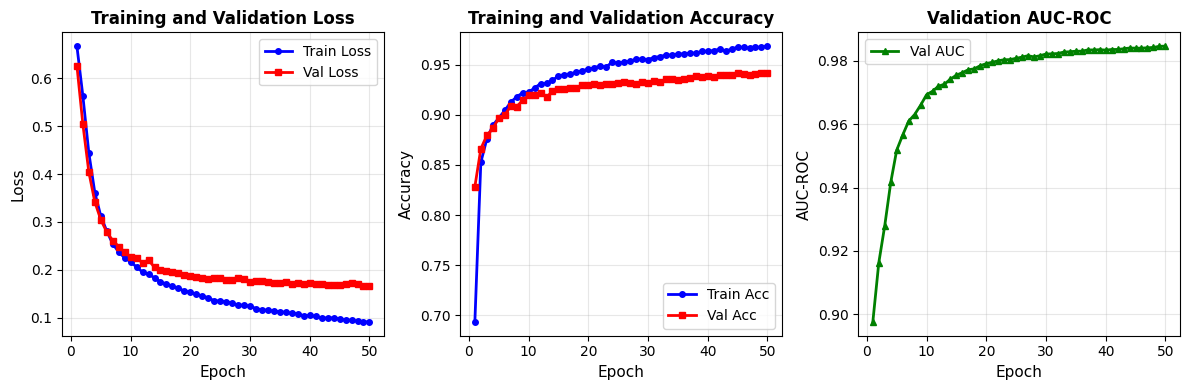

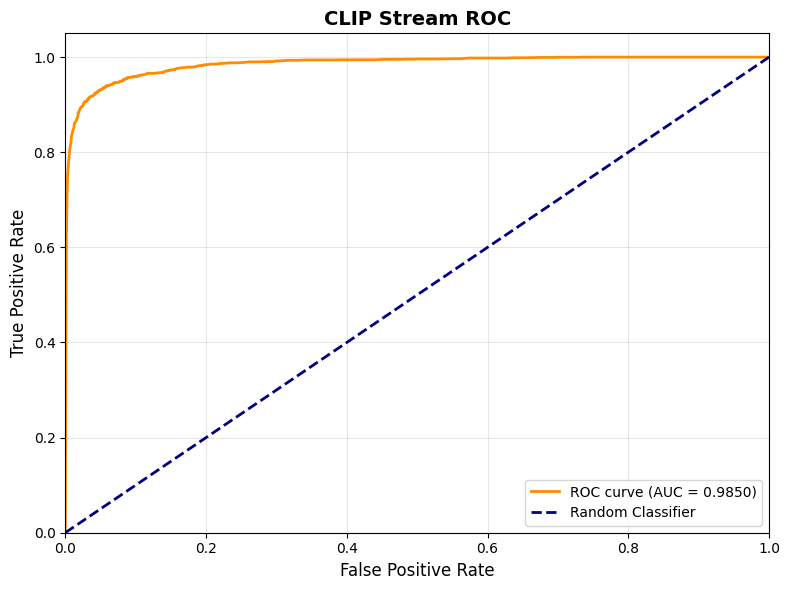

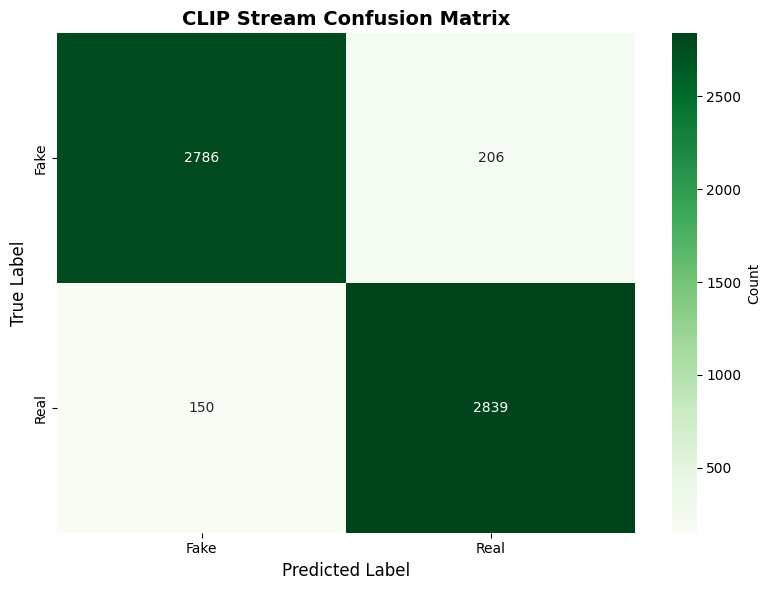

In [31]:
plot_training_history(
    history['train_loss'], history['val_loss'],
    history['train_acc'], history['val_acc'], history['val_auc'],
    save_path='../results/clip_training_curves.png',
)

labels_fake = (test_results['all_labels'] == 0).astype(int)
plot_roc_curve(labels_fake, test_results['all_probs'],
               title='CLIP Stream ROC', save_path='../results/clip_roc.png')
plot_confusion_matrix(test_results['all_labels'], test_results['all_preds'],
                      title='CLIP Stream Confusion Matrix',
                      save_path='../results/clip_cm.png');